# Region embeddings from seqlet annotations

Seqlet-level information aggregated back to the regions the seqlets came from.

Needs a clustered seqlet AnnData from the previous tutorials, with:

- `obsm["X_pca"]` (written by {func}`~tfmindi.tl.embed_and_cluster`) for the default `"pca"` embedding
- `obs["attribution"]` for the attribution-weighted embedding (default, recommended)
- an annotation column in `.obs` for count-vector embeddings and region profiles
- a column grouping regions, e.g. `obs["cell_type"]`, to find an optimal clustering

In [1]:
import tfmindi as tm

/home/VIB.LOCAL/bram.stuyven/miniforge3/envs/MINDI/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
seqlet_adata = tm.load_h5ad("tutorial_data/seqlets_clustered.h5ad")

The attribution, cell type and annotation columns:

In [5]:
seqlet_adata.obs[["attribution", "cell_type", "predicted_5.0_predicted_family_no_cl"]].head()

,attribution,cell_type,predicted_5.0_predicted_family_no_cl
0,3.002375,perivascular-macrophage_fragments_tsv,Homeobox
1,3.939682,perivascular-macrophage_fragments_tsv,TF_bZIP
2,2.042241,perivascular-macrophage_fragments_tsv,zf-C2H2
3,5.572167,perivascular-macrophage_fragments_tsv,bHLH
4,10.508435,perivascular-macrophage_fragments_tsv,IRF


## Region embeddings from the seqlet PCA

{func}`~tfmindi.tl.embed_regions` averages each region's seqlet PCA coordinates, weighted by
attribution, and computes a t-SNE on the result.

In [6]:
region_adata = tm.tl.embed_regions(seqlet_adata)

 [embed] embedding='pca', secondary='50', weighted, normalised
 [embed] Calculating weights
 [embed] Calculating pca embeddings on obsm.X_pca
 [embed] Calculating TSNE reduction...


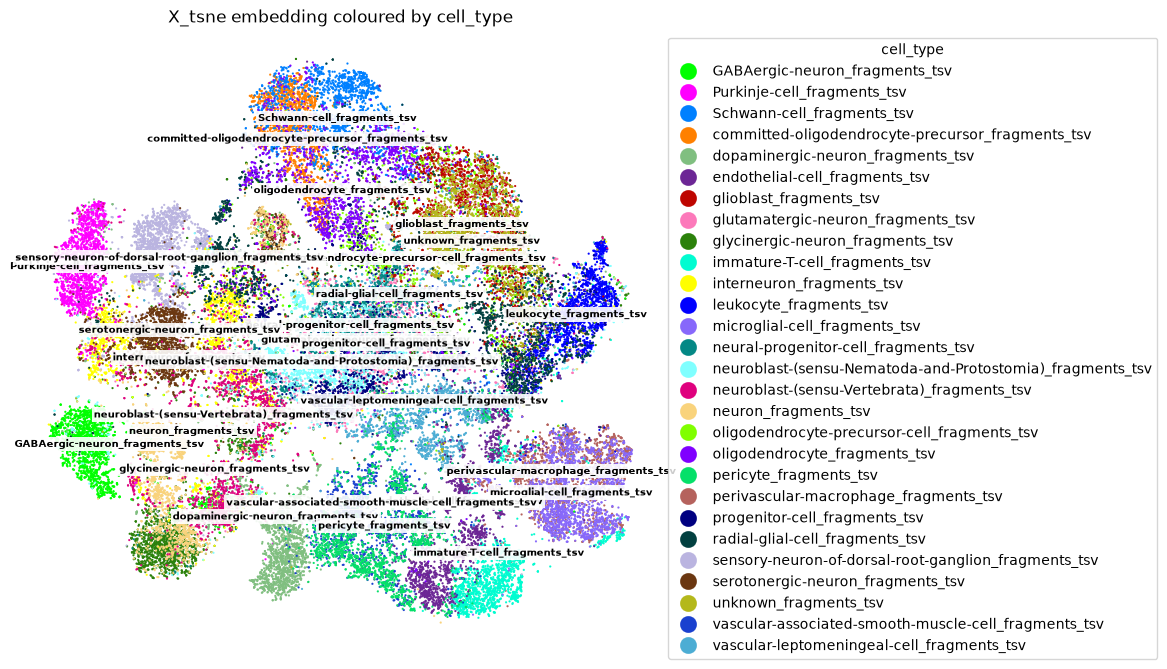

In [14]:
palette = tm.pl.tsne(region_adata, color_by='cell_type', fig_edge=9, dot_size=2, plot_labels=True)

## Count vector embeddings

Instead of averaging coordinates, count how often each annotation occurs per region.

In [15]:
region_adata_count = tm.tl.embed_regions(
    seqlet_adata,
    embedding="count",
    secondary="predicted_5.0_predicted_family",
    normalised=False,
)

 [embed] embedding='count', secondary='predicted_5.0_predicted_family', weighted, unnormalised
 [embed] Calculating weights
 [embed] Calculating count embeddings by constructing count vectors at adata.obs['predicted_5.0_predicted_family'] resolution
 [embed] Calculating TSNE reduction...


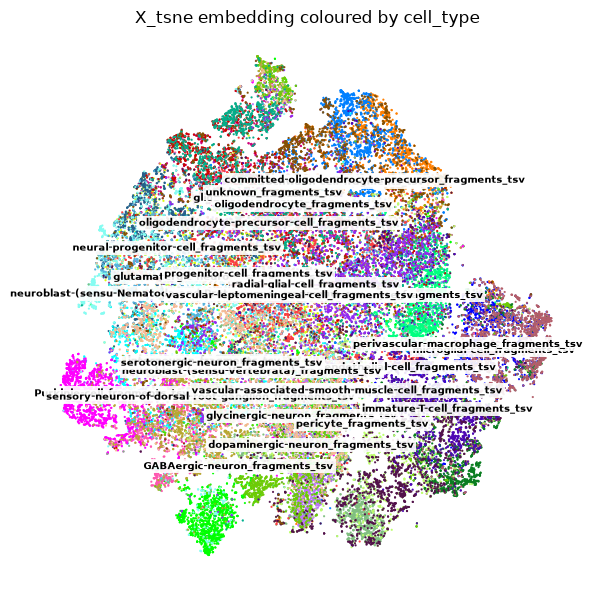

In [19]:
_ = tm.pl.tsne(region_adata_count, color_by='cell_type', fig_edge=6, dot_size=2, plot_labels=True, show_legend=False)

## Finding the best clustering of the embeddings

{func}`~tfmindi.tl.optimal_hierarchical_clustering` sweeps cut heights and keeps the one whose
clusters best agree with an existing region label (here `cell_type`).

 [clustering] Seeding embedding space with leiden clusters...
 [clustering] Build hierarchical tree...
 [clustering] Cutting at height 0.99
 [clustering] The optimal resolution is 0.17 with an ARI of 0.2983986237721502
 [clustering] Saved clusters in .obs region_cluster
 [clustering] Plotting...


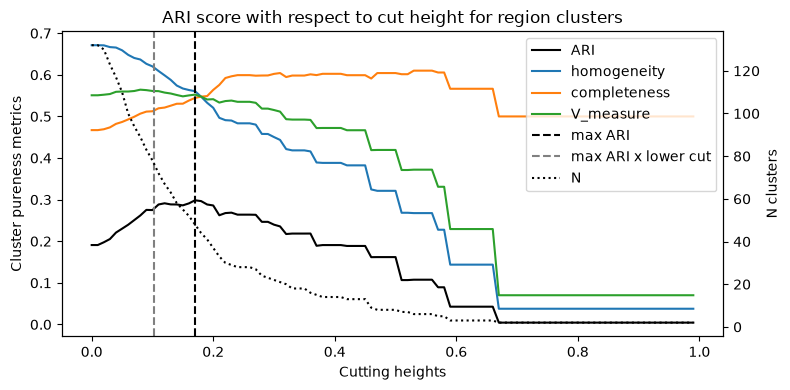

(0.17, np.float64(0.2983986237721502))

In [20]:
tm.tl.optimal_hierarchical_clustering(region_adata, lower_cut=0.6)

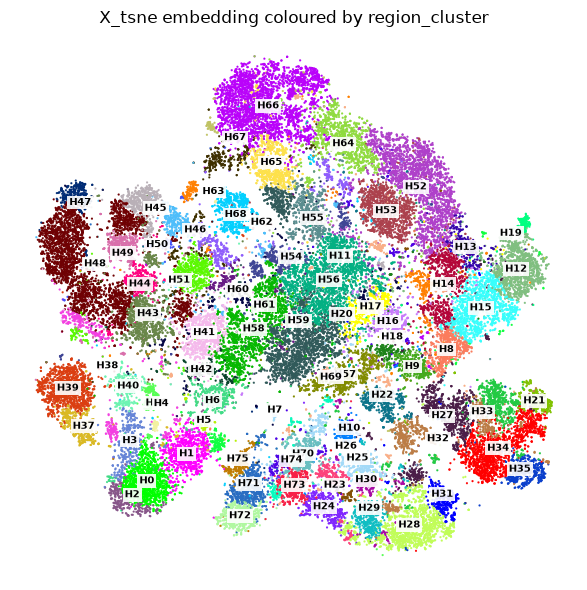

In [23]:
_ = tm.pl.tsne(region_adata, color_by='region_cluster', fig_edge=6, dot_size=2, plot_labels=True, show_legend=False)

## Region cluster profiles

Which motifs drive each region cluster.

In [26]:
profiles = tm.tl.get_region_profiles(
    seqlet_adata,
    region_adata,
    annotation_col="predicted_5.0_predicted_family",
    region_cluster_col="region_cluster",
)

/home/VIB.LOCAL/bram.stuyven/miniforge3/envs/MINDI/lib/python3.12/functools.py:912: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)


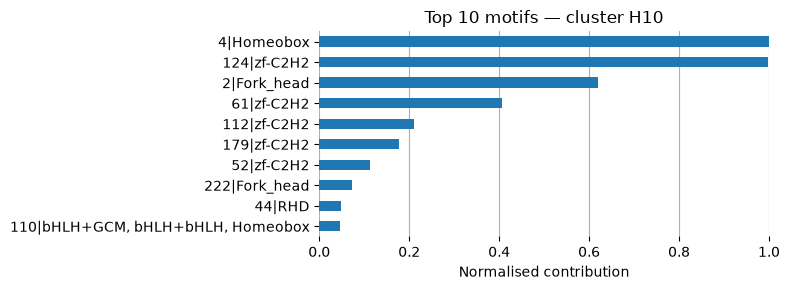

In [27]:
tm.pl.plot_top_motifs(profiles, region_cluster="H10")

## Save the region object

In [16]:
tm.save_h5ad(region_adata, "tutorial_data/regions.h5ad")

... storing 'leiden' as categorical
... storing 'region_cluster' as categorical
